In [10]:
import sys
sys.path.append('../../src')

In [11]:
from PIL import Image, ImageDraw, ImageFont, ImageOps
from matplotlib import pyplot as plt

from modules.palette_generation import get_asciis

In [12]:
asciis = "".join(get_asciis())

print(asciis)

0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~ 


In [13]:
fnt = ImageFont.truetype("../../fonts/FiraCode-Regular.ttf", 11)
bbox = fnt.getbbox(asciis)
width, height = bbox[2], bbox[3]
letter_width = width / len(asciis)

print(bbox)
print(width, height)
print(letter_width)
print(height / letter_width)

(0, 1, 570, 14)
570 14
6.0
2.3333333333333335


In [14]:
img = Image.new(mode="L", size=(width, height), color=(0))
img_d = ImageDraw.Draw(img)

img_d.text((0,0), asciis, font=fnt, fill=(255))

img

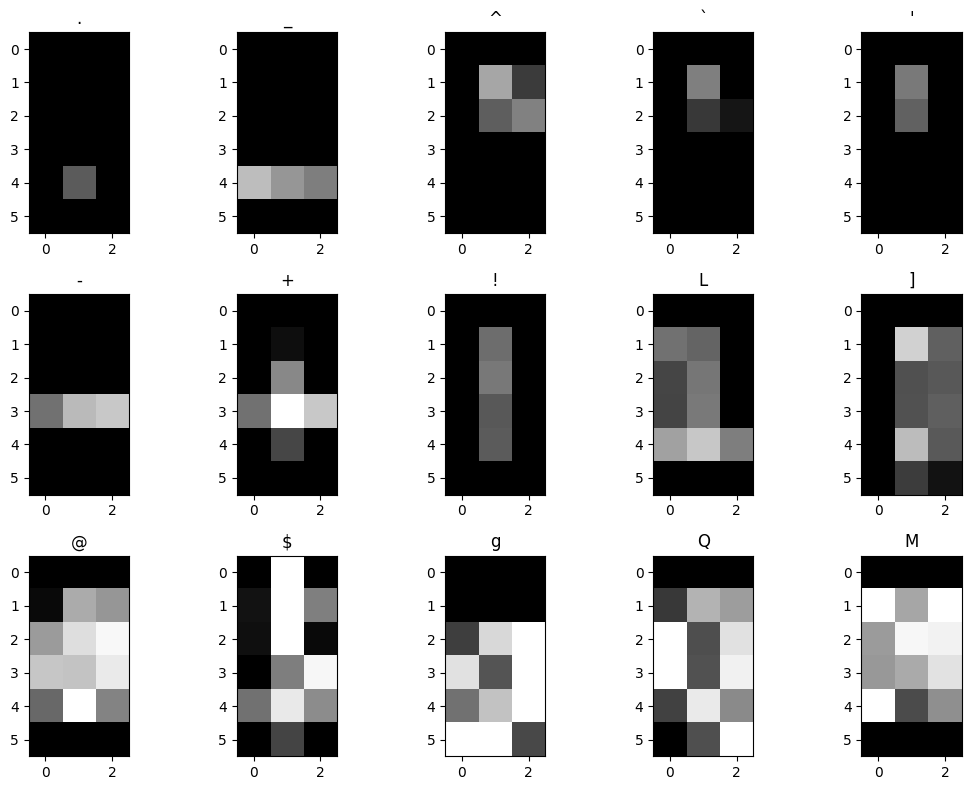

In [39]:
from modules.palette_generation import make_symbol2value_map

char_set = "._^`'-+!L]@$gQM"
symb2val_map = make_symbol2value_map(char_set, fnt, val_width=3, val_height=6, normalize=True)
fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(12, 8), layout='tight')
for i, (symb, val) in enumerate(symb2val_map.items()):
    ax = axs[i//axs.shape[1]][i%axs.shape[1]]
    ax.imshow(val, interpolation='nearest', cmap='gray', vmin=0, vmax=1)
    ax.set_title(symb)


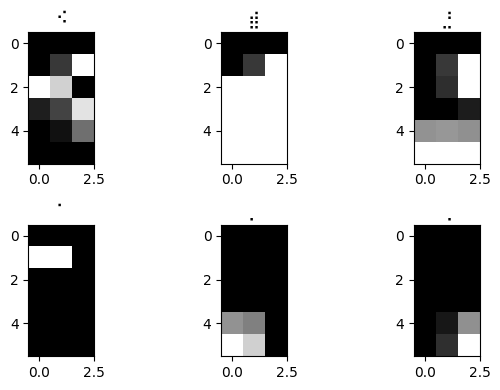

In [36]:
char_set = "⠪⣾⣘⠁⡀⢀"
symb2val_map = make_symbol2value_map(char_set, fnt, val_width=3, val_height=6, normalize=True)
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(8, 4), layout='tight')
for i, (symb, val) in enumerate(symb2val_map.items()):
    ax = axs[i//axs.shape[1]][i%axs.shape[1]]
    ax.imshow(val, interpolation='nearest', cmap='gray', vmin=0, vmax=1)
    ax.set_title(symb)


19
dict_keys(['@', '/g', 'g/', '.g', 'g.', '/$', '$/', '.$', '$.', '__', '/_', '_/', '._', '_.', '//', '../', './.', '/..', '...'])


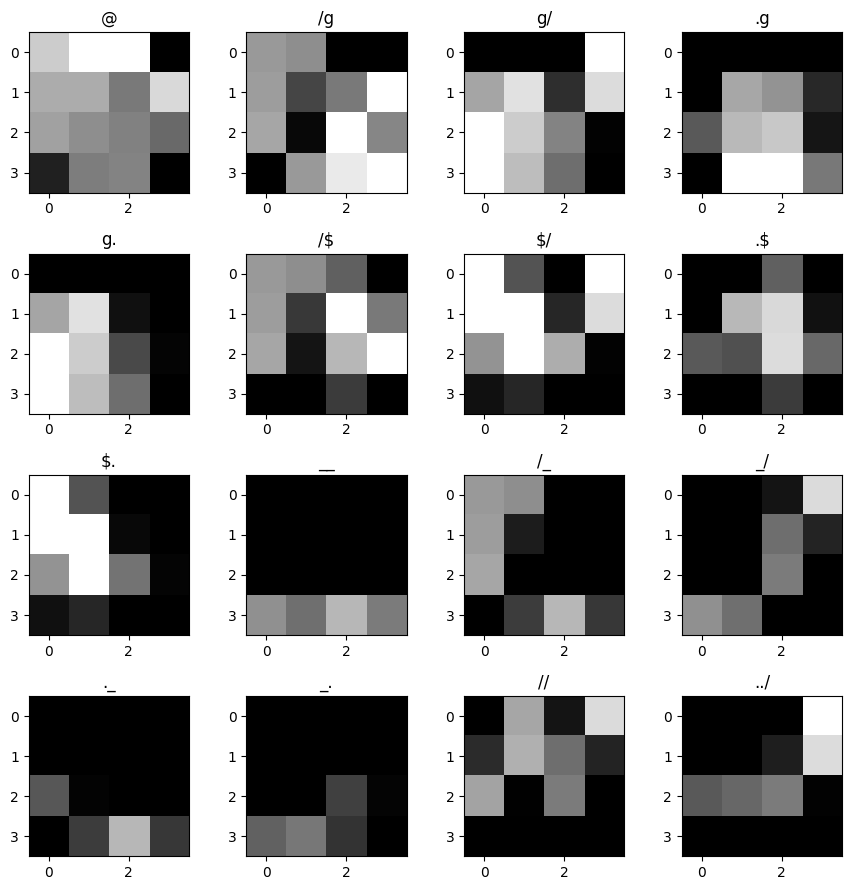

In [35]:
from modules.palette_generation import generate_non_mono_width_aligned_permutations

fnt_non_mono = ImageFont.truetype("../../fonts/OpenSans-Regular.ttf", 11)
char_set = "._/$@g"
char_set = generate_non_mono_width_aligned_permutations(char_set, fnt_non_mono)
symb2val_map = make_symbol2value_map(char_set, fnt_non_mono, val_width=4, val_height=4, normalize=True)
print(len(symb2val_map))
print(symb2val_map.keys())
nrows, ncols = 4, 4
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(9, 9), layout='tight')
for i, (symb, val) in enumerate(symb2val_map.items()):
    if i >= nrows * ncols:
        break
    ax = axs[i//axs.shape[1]][i%axs.shape[1]]
    ax.imshow(val, interpolation='nearest', cmap='gray', vmin=0, vmax=1)
    ax.set_title(symb)